# Test of InstaSHAP

In [3]:
import torch
import numpy as np
import copy
import os
from torch.utils.data import TensorDataset, DataLoader

from sian.models import TrainingArgs

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.instashap import surrogate, InstaSHAP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Step1: Prepare the data
use the bike_sharing data as in the paper https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [4]:
dataset_str = "bike_sharing" 
data_base_path = "../data/"
dataset_path = data_base_path + dataset_str + "/"

In [5]:
def preprocess_bike_sharing_dataset(load_dataset_path):
    import numpy as np
    
    csv_path = os.path.join(load_dataset_path, 'hour.csv')
    print(f"Processing file: {csv_path}")
    
    file = open(csv_path, 'r')
    lines = file.readlines()
    file.close()
    
    header = lines[0]
    data_lines = lines[1:]
    N = len(data_lines)
    bike_share_data = np.zeros((N, 17))

    for i, line in enumerate(data_lines):
        values = line.strip().split(',')
        day = int(values[1][8:10])
        values[1] = day

        bike_share_data[i] = [float(val) for val in values]
        
    # 1. Drop the first column (instant ID) -> 16 columns left
    bike_share_data = bike_share_data[:, 1:] 
    
    # 2. Log transform specific columns (casual, registered, cnt)
    bike_share_data[:, 13:16] = np.log(1 + bike_share_data[:, 13:16])
    
    # 3. extract X (Features) and Y (Target)
    
    X = bike_share_data[:, :13]  # Features: dteday(modified) to windspeed
    Y = bike_share_data[:, 15]   # Target: cnt (total count)
    
    XY_stuff = (X, Y, None, False, None)

    # Labels 
    readable_labels = {
        0 : "day", 1 : "season", 2 : "year", 3 : "month", 4 : "hour",
        5 : "holiday", 6 : "day of week", 7 : "workday",
        8 : "weather", 9 : "temperature", 10 : "feels_like_temp",
        11 : "humidity", 12 : "wind speed",
    }
    
    
    full_readable_labels = {
        'task_type' : "regression",
    }
    
    label_stuff = (readable_labels, full_readable_labels)
    print('--- processed and NOT saved ---')

    return XY_stuff, label_stuff

In [6]:
class CustomBikeDataset:
    def __init__(self, data_path, seed=None):
        XY_stuff, label_stuff = preprocess_bike_sharing_dataset(data_path)
        
        raw_X, raw_Y = XY_stuff[0], XY_stuff[1]

        if len(raw_Y.shape) == 1:
            raw_Y = raw_Y[:, None]
        
        total_len = raw_X.shape[0]
        test_split_idx = int(total_len * 0.8)

        self.trnvalX = raw_X[:test_split_idx]
        self.trnvalY = raw_Y[:test_split_idx]
        self.tstX = raw_X[test_split_idx:]
        self.tstY = raw_Y[test_split_idx:]

        self.trnX, self.valX, self.trnY, self.valY = None, None, None, None

        self.readable_labels = label_stuff[0]
        
        self.label_stuff_dict = {
            "readable_labels": self.readable_labels,
            "full_readable_labels": {
                "task_type": "regression",
                "D0": self.trnvalX.shape[1]
            }
        }

    def shuffle_and_split_trnval(self, trnval_shuffle_seed=None, trnval_split_percentage=0.7):
        if trnval_shuffle_seed is None:
            np.random.seed(None)
            self.trnval_shuffle_seed = np.random.randint(0, 10000)
        else:
            self.trnval_shuffle_seed = trnval_shuffle_seed
            
        np.random.seed(self.trnval_shuffle_seed)
        print('trnval_shuffle_seed:', self.trnval_shuffle_seed)

        M_NUM = self.trnvalX.shape[0]
        rand_indices = np.random.permutation(M_NUM)
        M_TRN_NUM = int(M_NUM * trnval_split_percentage)
        
        self.trnX = self.trnvalX[rand_indices[:M_TRN_NUM]]
        self.valX = self.trnvalX[rand_indices[M_TRN_NUM:]]
        self.trnY = self.trnvalY[rand_indices[:M_TRN_NUM]]
        self.valY = self.trnvalY[rand_indices[M_TRN_NUM:]]

    def pull_data(self):
        return (self.trnvalX, self.trnvalY, self.tstX, self.tstY)

    def pull_trnval_data(self):
        if self.trnX is None:
            raise Exception("Please call shuffle_and_split_trnval() first!")
        return (self.trnX, self.trnY, self.valX, self.valY)

    def get_D(self):
        return self.trnvalX.shape[1]
        
    def get_C(self):
        return self.trnvalY.shape[1]

    def get_dataset_id(self):
        return "bike_sharing_custom"
        
    def get_readable_labels(self):
        return self.label_stuff_dict["readable_labels"]
        
    def get_full_readable_labels(self):
        return self.label_stuff_dict["full_readable_labels"]

    def get_task_type(self):
        return self.get_full_readable_labels()["task_type"]

    def get_grouped_feature_dict(self):
        D = self.get_D()
        
        grouped_features_dict = {}
        grouped_features_dict["D"] = D
        grouped_features_dict["D0"] = D
        
        for i in range(D):
            grouped_features_dict[i] = [i]
            
        return grouped_features_dict

In [7]:
print("Initializing Custom Dataset...")
dataset_obj = CustomBikeDataset(dataset_path, seed=37)
dataset_obj.shuffle_and_split_trnval()
print(f"Dataset ready. X shape: {dataset_obj.trnX.shape}, Y shape: {dataset_obj.trnY.shape}")

Initializing Custom Dataset...
Processing file: ../data/bike_sharing/hour.csv
--- processed and NOT saved ---
trnval_shuffle_seed: 3141
Dataset ready. X shape: (9732, 13), Y shape: (9732, 1)


## Step2: Train Mask MLP
find the interactions

trnval_shuffle_seed: 0
trnX trnY (9732, 13) (9732, 1)
Epoch 0
MSE for train and val: 2.086598599980265, 2.024474609536543
--- 0.203 seconds in epoch ---
Epoch 1
MSE for train and val: 1.0829970030748999, 1.0445841626035972
--- 0.197 seconds in epoch ---
Epoch 2
MSE for train and val: 2.049729461287492, 2.0646414753396503
--- 0.181 seconds in epoch ---
Epoch 3
MSE for train and val: 0.993942412718351, 0.9859119425386096
--- 0.215 seconds in epoch ---
Epoch 4
MSE for train and val: 0.7792052588543742, 0.7797886090688679
--- 0.179 seconds in epoch ---
Epoch 5
MSE for train and val: 0.8418076870310423, 0.8487117902124506
--- 0.193 seconds in epoch ---
Epoch 6
MSE for train and val: 1.4113782442213754, 1.4346716608216195
--- 0.184 seconds in epoch ---
Epoch 7
MSE for train and val: 0.7691664534603929, 0.7887824092947768
--- 0.186 seconds in epoch ---
Epoch 8
MSE for train and val: 0.4258125051695083, 0.4301784956263808
--- 0.188 seconds in epoch ---
Epoch 9
MSE for train and val: 0.48797949

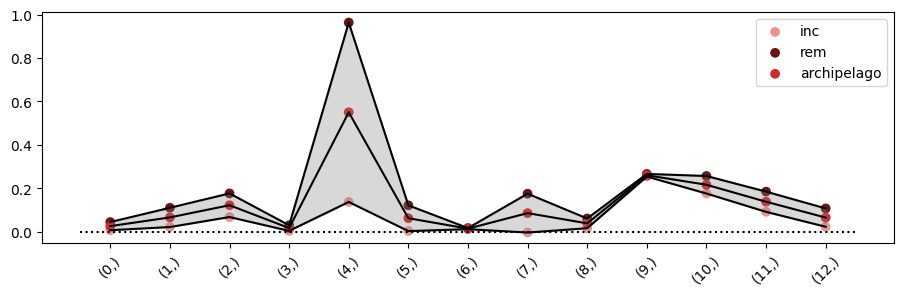

new_selections [(4,)]
selections [(4,)]
new_cands []
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (9,), (10,), (11,), (12,)]
0.10041117668151855 seconds
nr 1
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


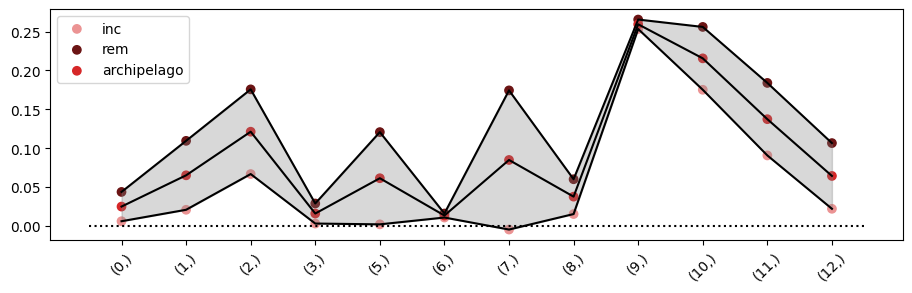

new_selections [(9,)]
selections [(4,), (9,)]
new_cands [(4, 9)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (10,), (11,), (12,), (4, 9)]
0.2069721221923828 seconds
nr 2
archipelago_tensor (12, 2, 4171)
semitruth torch.Size([4171, 1])


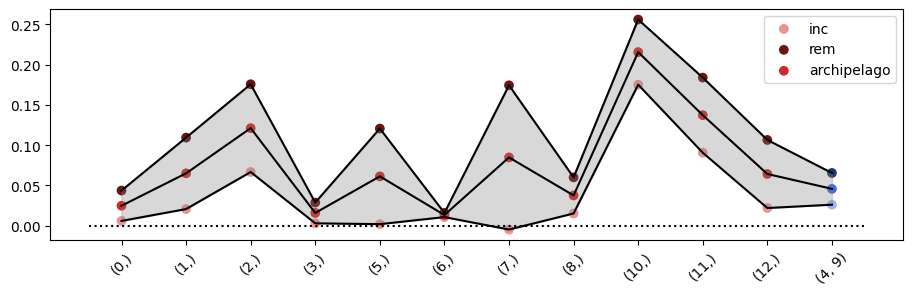

new_selections [(10,)]
selections [(4,), (9,), (10,)]
new_cands [(4, 9), (4, 10), (9, 10)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (11,), (12,), (4, 9), (4, 10), (9, 10)]
0.2900221347808838 seconds
nr 3
archipelago_tensor (13, 2, 4171)
semitruth torch.Size([4171, 1])


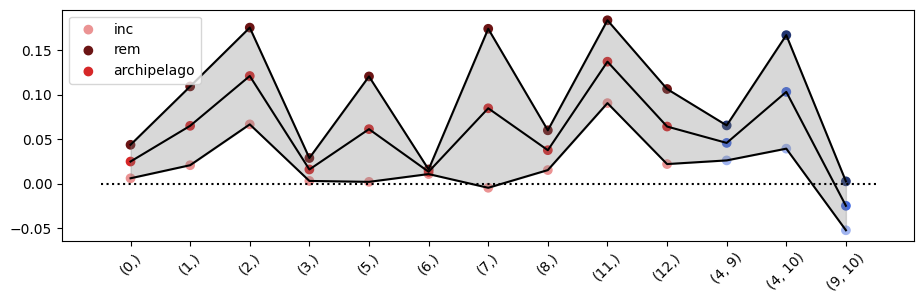

new_selections [(11,)]
selections [(4,), (9,), (10,), (11,)]
new_cands [(4, 9), (4, 10), (4, 11), (9, 10), (9, 11), (10, 11)]
candidates [(0,), (1,), (2,), (3,), (5,), (6,), (7,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11)]
0.3816182613372803 seconds
nr 4
archipelago_tensor (15, 2, 4171)
semitruth torch.Size([4171, 1])


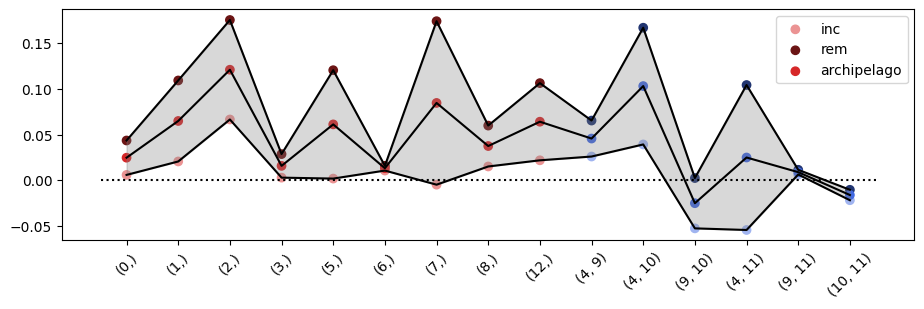

new_selections [(2,)]
selections [(4,), (9,), (10,), (11,), (2,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (9, 10), (9, 11), (2, 9), (10, 11), (2, 10), (2, 11)]
candidates [(0,), (1,), (3,), (5,), (6,), (7,), (8,), (12,), (4, 9), (4, 10), (9, 10), (4, 11), (9, 11), (10, 11), (2, 4), (2, 9), (2, 10), (2, 11)]
0.497607946395874 seconds
nr 5
archipelago_tensor (18, 2, 4171)
semitruth torch.Size([4171, 1])


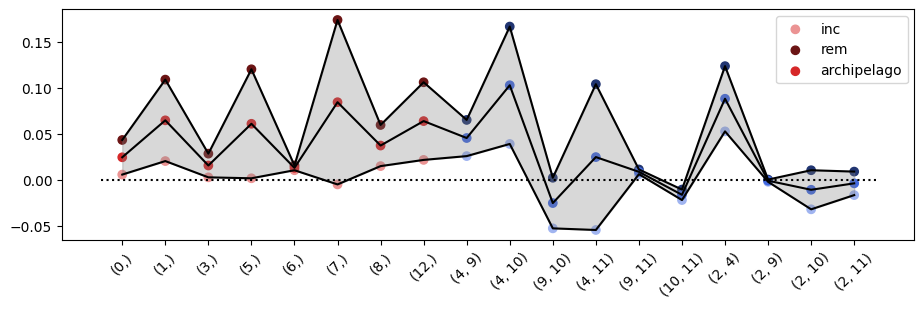

new_selections [(4, 10)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (9, 10), (9, 11), (2, 9), (10, 11), (2, 10), (2, 11)]
candidates [(0,), (1,), (3,), (5,), (6,), (7,), (8,), (12,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 4), (2, 9), (2, 10), (2, 11)]
0.6206541061401367 seconds
nr 6
archipelago_tensor (17, 2, 4171)
semitruth torch.Size([4171, 1])


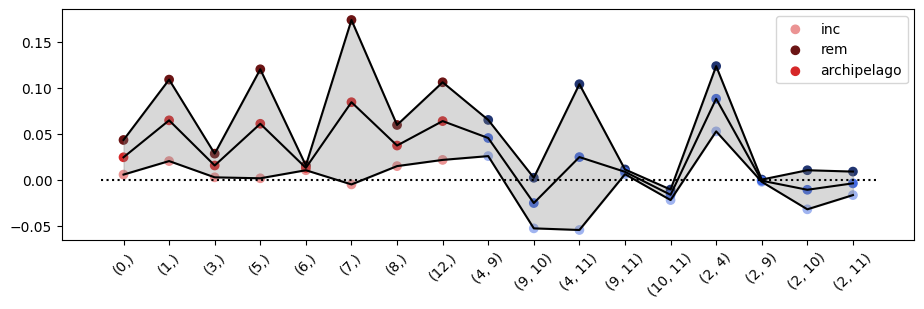

new_selections [(2, 4)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (9, 10), (9, 11), (2, 9), (10, 11), (2, 10), (2, 11)]
candidates [(0,), (1,), (3,), (5,), (6,), (7,), (8,), (12,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11)]
0.737962007522583 seconds
nr 7
archipelago_tensor (16, 2, 4171)
semitruth torch.Size([4171, 1])


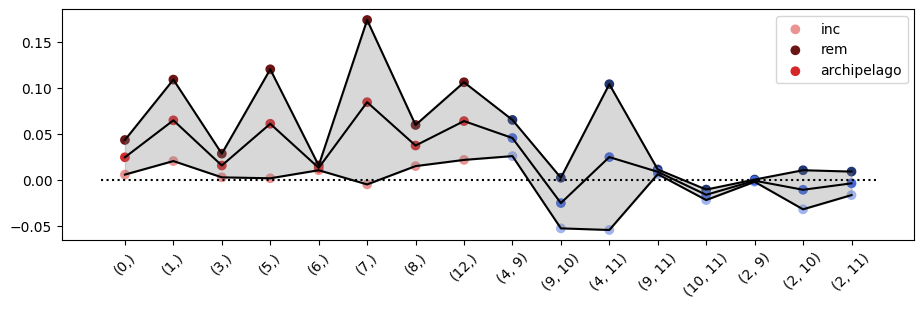

new_selections [(7,)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (9, 10), (9, 11), (2, 9), (7, 9), (10, 11), (2, 10), (7, 10), (2, 11), (7, 11), (2, 7)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (4, 7), (7, 9), (7, 10), (7, 11), (2, 7)]
0.8486001491546631 seconds
nr 8
archipelago_tensor (20, 2, 4171)
semitruth torch.Size([4171, 1])


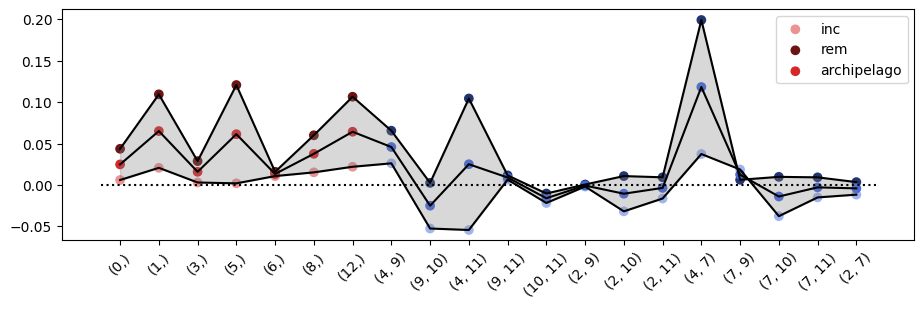

new_selections [(4, 7)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (9, 10), (9, 11), (2, 9), (7, 9), (10, 11), (2, 10), (7, 10), (2, 11), (7, 11), (2, 7)]
candidates [(0,), (1,), (3,), (5,), (6,), (8,), (12,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7)]
0.9968283176422119 seconds
nr 9
archipelago_tensor (19, 2, 4171)
semitruth torch.Size([4171, 1])


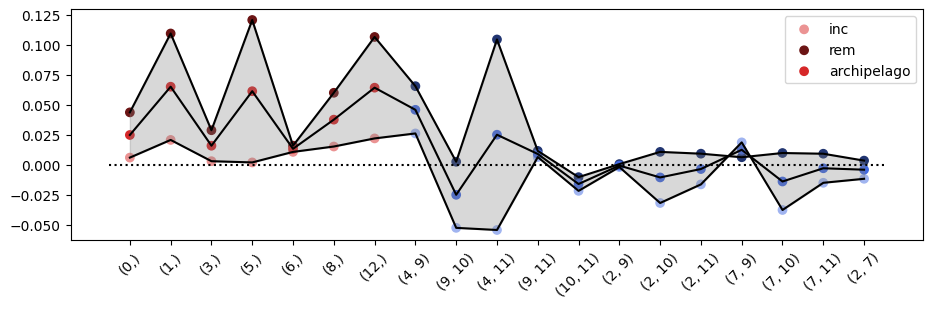

new_selections [(1,)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (10, 11), (2, 10), (7, 10), (1, 10), (2, 11), (7, 11), (1, 11), (2, 7), (1, 2), (1, 7)]
candidates [(0,), (3,), (5,), (6,), (8,), (12,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 4), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7)]
1.1311302185058594 seconds
nr 10
archipelago_tensor (24, 2, 4171)
semitruth torch.Size([4171, 1])


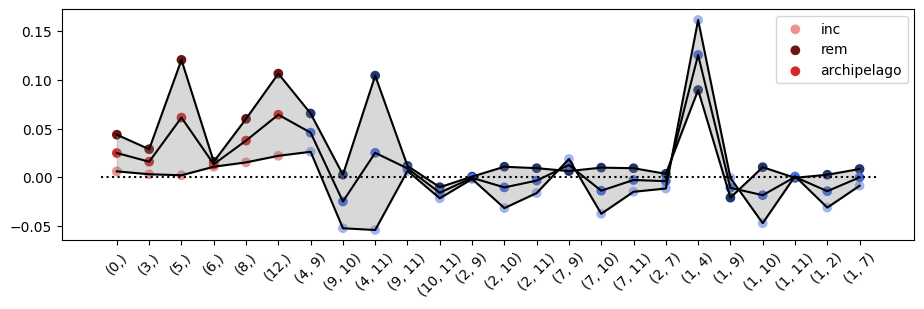

new_selections [(1, 4)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (10, 11), (2, 10), (7, 10), (1, 10), (2, 11), (7, 11), (1, 11), (2, 7), (1, 2), (1, 7)]
candidates [(0,), (3,), (5,), (6,), (8,), (12,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7)]
1.2809741497039795 seconds
nr 11
archipelago_tensor (23, 2, 4171)
semitruth torch.Size([4171, 1])


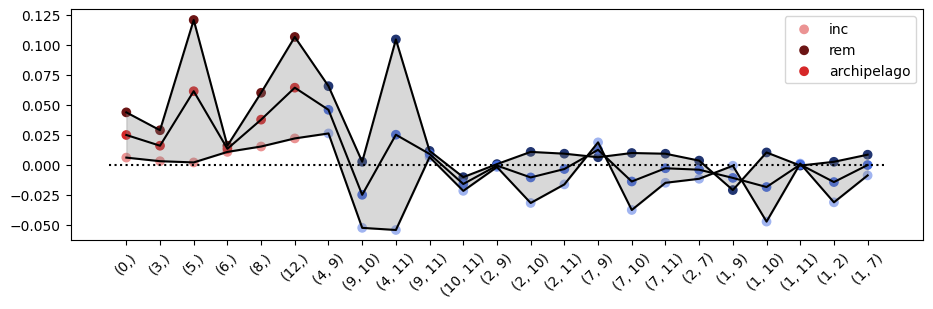

new_selections [(12,)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (2, 11), (7, 11), (1, 11), (11, 12), (2, 7), (1, 2), (2, 12), (1, 7), (7, 12), (1, 12)]
candidates [(0,), (3,), (5,), (6,), (8,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (4, 12), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12)]
1.4271240234375 seconds
nr 12
archipelago_tensor (29, 2, 4171)
semitruth torch.Size([4171, 1])


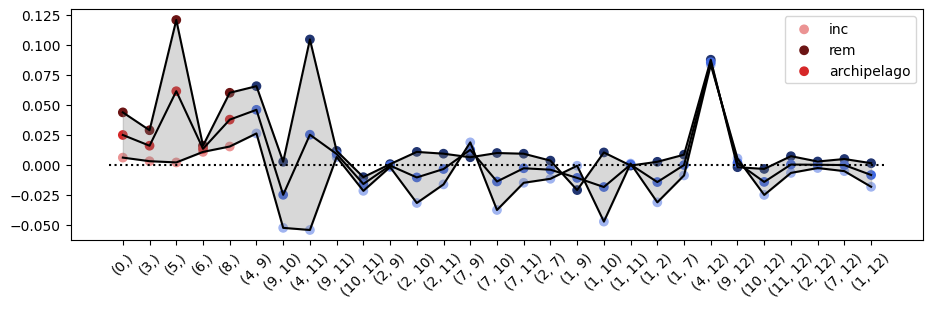

new_selections [(4, 12)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (2, 11), (7, 11), (1, 11), (11, 12), (2, 7), (1, 2), (2, 12), (1, 7), (7, 12), (1, 12)]
candidates [(0,), (3,), (5,), (6,), (8,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12)]
1.6160352230072021 seconds
nr 13
archipelago_tensor (28, 2, 4171)
semitruth torch.Size([4171, 1])


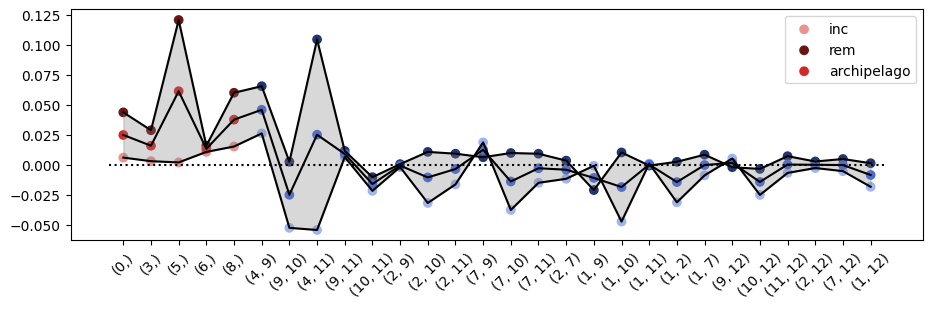

new_selections [(5,)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (2, 7), (1, 2), (2, 12), (2, 5), (1, 7), (7, 12), (5, 7), (1, 12), (1, 5), (5, 12)]
candidates [(0,), (3,), (6,), (8,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (4, 5), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12)]
1.7795791625976562 seconds
nr 14
archipelago_tensor (35, 2, 4171)
semitruth torch.Size([4171, 1])


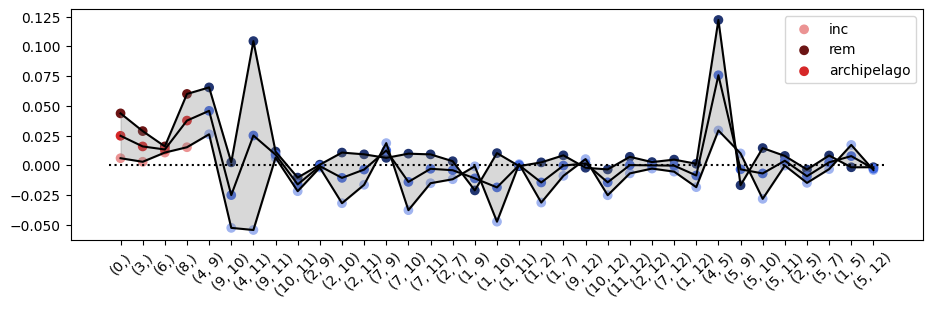

new_selections [(4, 5)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (2, 7), (1, 2), (2, 12), (2, 5), (1, 7), (7, 12), (5, 7), (1, 12), (1, 5), (5, 12)]
candidates [(0,), (3,), (6,), (8,), (4, 9), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12)]
1.9786529541015625 seconds
nr 15
archipelago_tensor (34, 2, 4171)
semitruth torch.Size([4171, 1])


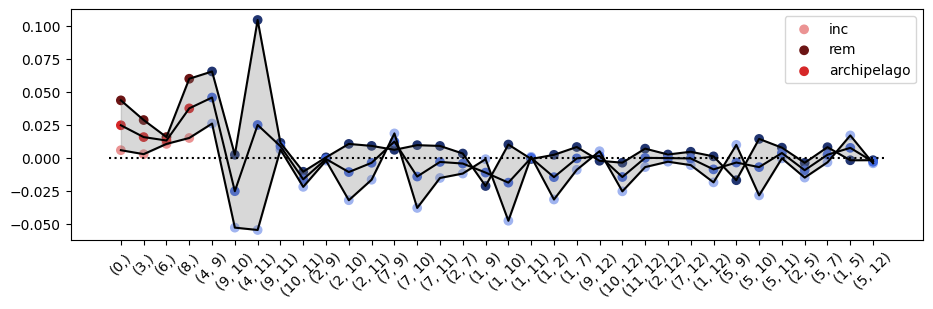

new_selections [(4, 9)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5), (4, 9)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (2, 7), (1, 2), (2, 12), (2, 5), (1, 7), (7, 12), (5, 7), (1, 12), (1, 5), (5, 12)]
candidates [(0,), (3,), (6,), (8,), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12)]
2.2599129676818848 seconds
nr 16
archipelago_tensor (33, 2, 4171)
semitruth torch.Size([4171, 1])


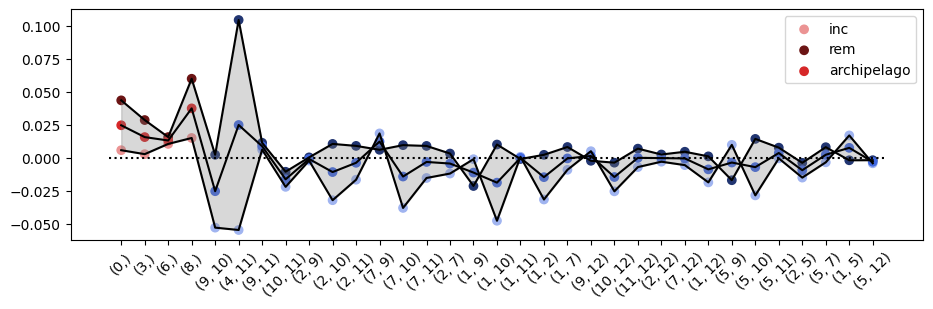

new_selections [(8,)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5), (4, 9), (8,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (4, 8), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (8, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (8, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (8, 11), (2, 7), (1, 2), (2, 12), (2, 5), (2, 8), (1, 7), (7, 12), (5, 7), (7, 8), (1, 12), (1, 5), (1, 8), (5, 12), (8, 12), (5, 8)]
candidates [(0,), (3,), (6,), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12), (4, 8), (8, 9), (8, 10), (8, 11), (2, 8), (7, 8), (1, 8), (8, 12), (5, 8)]
2.456977128982544 seconds
nr 17
archipelago_tensor (41, 2, 4171)
semitruth torch.Size([4

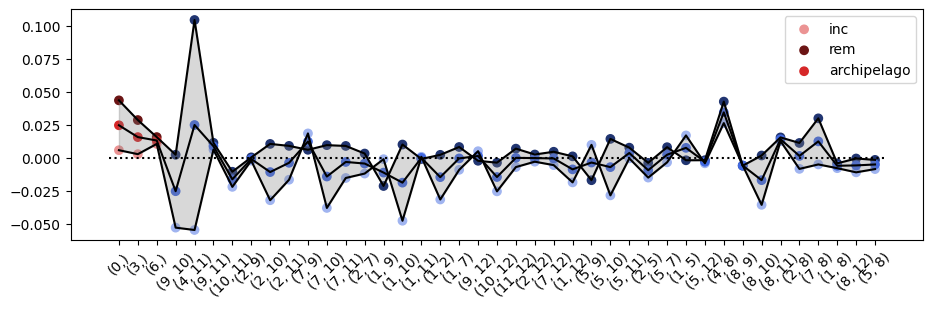

new_selections [(4, 8)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5), (4, 9), (8,), (4, 8)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (4, 8), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (8, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (8, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (8, 11), (2, 7), (1, 2), (2, 12), (2, 5), (2, 8), (1, 7), (7, 12), (5, 7), (7, 8), (1, 12), (1, 5), (1, 8), (5, 12), (8, 12), (5, 8)]
candidates [(0,), (3,), (6,), (9, 10), (4, 11), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12), (8, 9), (8, 10), (8, 11), (2, 8), (7, 8), (1, 8), (8, 12), (5, 8)]
2.692841053009033 seconds
nr 18
archipelago_tensor (40, 2, 4171)
semitruth torch.Size(

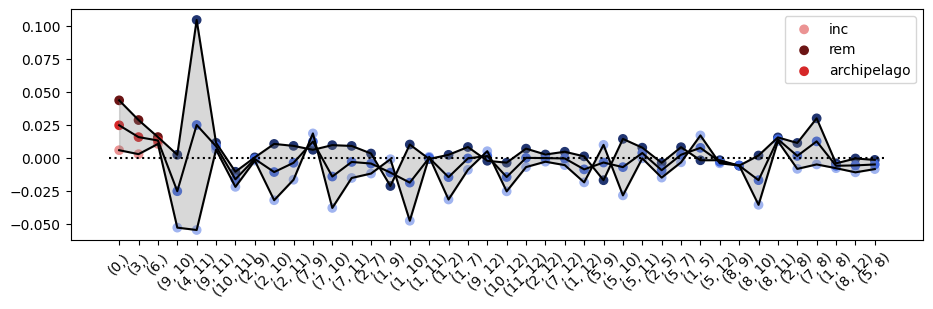

new_selections [(4, 11)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5), (4, 9), (8,), (4, 8), (4, 11)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (4, 8), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (8, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (8, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (8, 11), (2, 7), (1, 2), (2, 12), (2, 5), (2, 8), (1, 7), (7, 12), (5, 7), (7, 8), (1, 12), (1, 5), (1, 8), (5, 12), (8, 12), (5, 8)]
candidates [(0,), (3,), (6,), (9, 10), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12), (8, 9), (8, 10), (8, 11), (2, 8), (7, 8), (1, 8), (8, 12), (5, 8)]
2.939676284790039 seconds
nr 19
archipelago_tensor (39, 2, 4171)
semitruth torch.Size

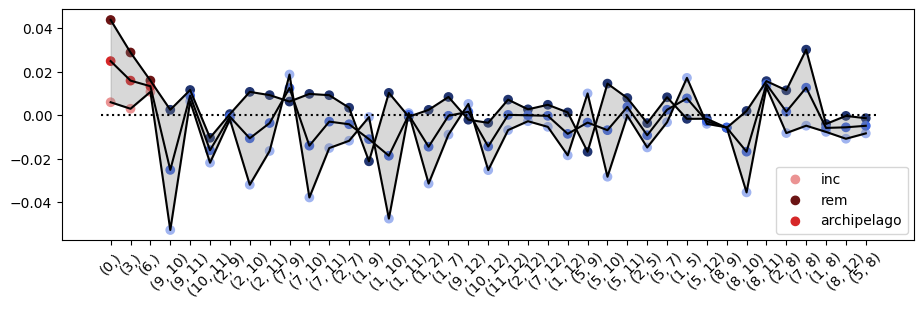

new_selections [(0,)]
selections [(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5), (4, 9), (8,), (4, 8), (4, 11), (0,)]
new_cands [(4, 9), (4, 10), (4, 11), (2, 4), (4, 7), (1, 4), (4, 12), (4, 5), (4, 8), (0, 4), (9, 10), (9, 11), (2, 9), (7, 9), (1, 9), (9, 12), (5, 9), (8, 9), (0, 9), (10, 11), (2, 10), (7, 10), (1, 10), (10, 12), (5, 10), (8, 10), (0, 10), (2, 11), (7, 11), (1, 11), (11, 12), (5, 11), (8, 11), (0, 11), (2, 7), (1, 2), (2, 12), (2, 5), (2, 8), (0, 2), (1, 7), (7, 12), (5, 7), (7, 8), (0, 7), (1, 12), (1, 5), (1, 8), (0, 1), (5, 12), (8, 12), (0, 12), (5, 8), (0, 5), (0, 8)]
candidates [(3,), (6,), (9, 10), (9, 11), (10, 11), (2, 9), (2, 10), (2, 11), (7, 9), (7, 10), (7, 11), (2, 7), (1, 9), (1, 10), (1, 11), (1, 2), (1, 7), (9, 12), (10, 12), (11, 12), (2, 12), (7, 12), (1, 12), (5, 9), (5, 10), (5, 11), (2, 5), (5, 7), (1, 5), (5, 12), (8, 9), (8, 10), (8, 11), (2, 8), (7, 8), (1, 8), (8, 12), (5, 8), (0, 4

In [8]:
results_path = "../results/"
exp_folder = results_path+'_'+ "demo" +'_simple_testing/'
os.makedirs(exp_folder, exist_ok=True)

mlp_args = TrainingArgs(batch_size=32, number_of_epochs=10, learning_rate=5e-3, device=device) 
mlp_args.model_config.net_name = "MLP"
mlp_args.model_config.sizes = [-1, 256, 128, 64, -1]
mlp_args.model_config.is_masked = True  
mlp_args.saving_settings.exp_folder = exp_folder
 
my_surrogate = surrogate(mlp_args=mlp_args, dataset_obj=dataset_obj)
interactions = my_surrogate.get_interactions(device=device)
transform_matrix = my_surrogate.get_transform_matrix()

print(f"\nFound interactions: {interactions}")

In [12]:
print(interactions)

[(4,), (9,), (10,), (11,), (2,), (4, 10), (2, 4), (7,), (4, 7), (1,), (1, 4), (12,), (4, 12), (5,), (4, 5), (4, 9), (8,), (4, 8), (4, 11), (0,)]


## Step3: train the InstaSHAP

In [10]:
# prepare DataLoader for InstaSHAP training
X_train = torch.from_numpy(dataset_obj.trnX).float().to(device)
Y_train = torch.from_numpy(dataset_obj.trnY).float().to(device)
y_mean = Y_train.mean() # normalization
Y_centered = Y_train - y_mean
train_dataset = TensorDataset(X_train, Y_centered)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# train the model
instashap_model = InstaSHAP(interactions, transform_matrix, device=device)
instashap_model.train_instaSHAP(train_loader, num_epochs=10, lr=1e-2, device=device)

Epoch 1/10: 100%|██████████| 305/305 [00:00<00:00, 577.21it/s]


Epoch 1, Loss: 2.4480


Epoch 2/10: 100%|██████████| 305/305 [00:00<00:00, 616.39it/s]


Epoch 2, Loss: 1.3893


Epoch 3/10: 100%|██████████| 305/305 [00:00<00:00, 613.41it/s]


...

Epoch 8, Loss: 1.2981


Epoch 9/10: 100%|██████████| 305/305 [00:00<00:00, 619.74it/s]


Epoch 9, Loss: 1.3092


Epoch 10/10: 100%|██████████| 305/305 [00:00<00:00, 611.72it/s]

Epoch 10, Loss: 1.2649


## Step4: evaluate the SHAP value

In [11]:
instashap_model.eval()
with torch.no_grad():

    sample_x = X_train[0:1]
    sample_y = Y_centered[0:1]
    
    # 预测 (全特征 Mask)
    full_mask = torch.ones_like(sample_x)
    pred = instashap_model(sample_x, full_mask)
    
    print(f"\nTest Sample 0:")
    print(f"True Centered Y: {sample_y.item():.4f}")
    print(f"Pred Centered Y: {pred.item():.4f}")

    shap = instashap_model.get_shapley_values(sample_x)
    print(f"SHAP values: {shap.cpu().numpy()}")


Test Sample 0:
True Centered Y: 1.3528
Pred Centered Y: -0.0702
SHAP values: [[ 0.2256935   0.27130464 -0.23091182  0.23227988  0.05638704 -0.36756748
   0.13959263 -0.31696507  0.14135198 -0.10897599  0.02879487  0.19447349
  -0.03761262  0.01161645 -0.22578742  0.00044351  0.06243408 -0.17514613
   0.02836209]]
